
## 1.1 Install PySpark
Install Java (required by Spark) and PySpark, then configure the environment.

In [1]:
# Install Java first (fixes JAVA_GATEWAY_EXITED error)
!apt-get update -q
!apt-get install openjdk-11-jdk -q
!pip install pyspark==3.5.1 -q

import os, pyspark
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PYSPARK_PYTHON"] = "python3"
print(f"PySpark {pyspark.__version__} ready")

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,369 B/s)
Reading package lists...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sourc

## 1.2 Create SparkSession
`SparkSession` is the entry point to all Spark functionality. `local[*]` uses all available CPU cores.

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("LNDN5204-CW3") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} | App: {spark.sparkContext.appName}")

Spark 3.5.1 | App: LNDN5204-CW3


## 2.1 Dataset: Diabetes 130-US Hospitals (1999–2008)

## 2.2 — Kaggle API Setup
Get your API key: kaggle.com → Profile → Settings → API → Create New Token → upload `kaggle.json` below.
(On Google Colab use the `files.upload()` cell shown here; this dataset is also downloadable from the UCI link above.)

In [3]:
!pip install kaggle -q
from google.colab import files
import shutil, zipfile, os

print("Upload your kaggle.json file when prompted...")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle API key configured")

import zipfile, shutil, csv

!kaggle datasets download -d abdelazizsami/diabetes-130-us-hospitals-for-years-1999-2008 --force -q

with zipfile.ZipFile("diabetes-130-us-hospitals-for-years-1999-2008.zip", "r") as z:
    z.extractall("diabetes_data")


shutil.copy("diabetes_data/diabetic_data.csv", "diabetic_data.csv")

print("Done: diabetic_data.csv")

Upload your kaggle.json file when prompted...


Saving kaggle.json to kaggle (1).json
Kaggle API key configured
Dataset URL: https://www.kaggle.com/datasets/abdelazizsami/diabetes-130-us-hospitals-for-years-1999-2008
License(s): apache-2.0
Done: diabetic_data.csv


## 3.1 Load CSV into Spark DataFrame
`inferSchema=True` auto-detects column types. `header=True` uses the first row as column names.

In [4]:
df = spark.read.csv("diabetic_data.csv", header=True, inferSchema=True)
print(f"Rows: {df.count():,} | Columns: {len(df.columns)}")
print(df.columns)

Rows: 101,766 | Columns: 50
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


## 3.2 Clean Column Names
Replace spaces with underscores so column names work in Spark SQL and DataFrame operations.

In [5]:
clean_cols = [c.strip().replace(" ", "_").replace("%", "pct") for c in df.columns]
df = df.toDF(*clean_cols)
print("Cleaned columns:", df.columns)

Cleaned columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


## 4.1 Inspect Schema
Always check the schema after loading. Watch for codes loaded as integers that are really categorical.

In [6]:
df.printSchema()

root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagnoses: integer (nullable = true)
 |-

## 4.2 Handle Missing Values

In [7]:
from pyspark.sql.functions import col, when, trim
from pyspark.sql.types import StringType

string_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]
for c in string_cols:
    df = df.withColumn(c, when(trim(col(c)) == "?", None).otherwise(col(c)))

print(f"Normalised '?' to NULL across {len(string_cols)} string columns")

Normalised '?' to NULL across 37 string columns


## 5.1 Preview the DataFrame
`.show()` prints rows to screen. `.first()` returns a single Row object.

In [8]:
print("First 5 rows:")
df.select("encounter_id","race","gender","age","time_in_hospital","readmitted").show(5, truncate=True)

First 5 rows:
+------------+---------------+------+-------+----------------+----------+
|encounter_id|           race|gender|    age|time_in_hospital|readmitted|
+------------+---------------+------+-------+----------------+----------+
|     2278392|      Caucasian|Female| [0-10)|               1|        NO|
|      149190|      Caucasian|Female|[10-20)|               3|       >30|
|       64410|AfricanAmerican|Female|[20-30)|               2|        NO|
|      500364|      Caucasian|  Male|[30-40)|               2|        NO|
|       16680|      Caucasian|  Male|[40-50)|               1|        NO|
+------------+---------------+------+-------+----------------+----------+
only showing top 5 rows



In [9]:
print("Vertical view (first row):")
df.show(1, vertical=True)

Vertical view (first row):
-RECORD 0----------------------------------------
 encounter_id             | 2278392              
 patient_nbr              | 8222157              
 race                     | Caucasian            
 gender                   | Female               
 age                      | [0-10)               
 weight                   | NULL                 
 admission_type_id        | 6                    
 discharge_disposition_id | 25                   
 admission_source_id      | 1                    
 time_in_hospital         | 1                    
 payer_code               | NULL                 
 medical_specialty        | Pediatrics-Endocr... 
 num_lab_procedures       | 41                   
 num_procedures           | 0                    
 num_medications          | 1                    
 number_outpatient        | 0                    
 number_emergency         | 0                    
 number_inpatient         | 0                    
 diag_1                

In [10]:
first_row = df.first()
print(f"Encounter: {first_row['encounter_id']} | Age: {first_row['age']} | Readmitted: {first_row['readmitted']}")

Encounter: 2278392 | Age: [0-10) | Readmitted: NO


## 6.1 Summary Statistics
`.describe()` returns count, mean, std, min, max for numeric columns.

In [11]:
df.select("time_in_hospital","num_lab_procedures","num_medications","number_inpatient","number_diagnoses").describe().show()

+-------+------------------+------------------+------------------+------------------+-----------------+
|summary|  time_in_hospital|num_lab_procedures|   num_medications|  number_inpatient| number_diagnoses|
+-------+------------------+------------------+------------------+------------------+-----------------+
|  count|            101766|            101766|            101766|            101766|           101766|
|   mean| 4.395986871843248| 43.09564098028811|16.021844230882614| 0.635565906098304|7.422606764538254|
| stddev|2.9851077674712636|19.674362249142053| 8.127566209167295|1.2628632900973216| 1.93360014499743|
|    min|                 1|                 1|                 1|                 0|                1|
|    max|                14|               132|                81|                21|               16|
+-------+------------------+------------------+------------------+------------------+-----------------+



In [12]:
from pyspark.sql.functions import countDistinct

for c in ["race","gender","age","admission_type_id","A1Cresult","insulin","diabetesMed","readmitted"]:
    n = df.select(countDistinct(c)).collect()[0][0]
    print(f"  {c:<22} {n} distinct values")

  race                   5 distinct values
  gender                 3 distinct values
  age                    10 distinct values
  admission_type_id      8 distinct values
  A1Cresult              4 distinct values
  insulin                4 distinct values
  diabetesMed            2 distinct values
  readmitted             3 distinct values


In [13]:
df.groupBy("readmitted").count().orderBy("count", ascending=False).show()

+----------+-----+
|readmitted|count|
+----------+-----+
|        NO|54864|
|       >30|35545|
|       <30|11357|
+----------+-----+



## 7.1 Selecting Columns
`.select()` chooses columns equivalent to SQL `SELECT`. Use `col()` for expressions.

In [14]:
from pyspark.sql.functions import col, round as spark_round

df.select(
    col("encounter_id"),
    col("race"),
    col("age"),
    col("time_in_hospital"),
    col("num_medications"),
    col("readmitted")
).show(5)

+------------+---------------+-------+----------------+---------------+----------+
|encounter_id|           race|    age|time_in_hospital|num_medications|readmitted|
+------------+---------------+-------+----------------+---------------+----------+
|     2278392|      Caucasian| [0-10)|               1|              1|        NO|
|      149190|      Caucasian|[10-20)|               3|             18|       >30|
|       64410|AfricanAmerican|[20-30)|               2|             13|        NO|
|      500364|      Caucasian|[30-40)|               2|             16|        NO|
|       16680|      Caucasian|[40-50)|               1|              8|        NO|
+------------+---------------+-------+----------------+---------------+----------+
only showing top 5 rows



## 7.2 Filtering Rows
`.filter()` keeps rows matching a condition equivalent to SQL `WHERE`.

In [15]:
emergency = df.filter(df["admission_type_id"] == 1)
print(f"Emergency admissions: {emergency.count():,}")
emergency.select("race","age","time_in_hospital","readmitted").show(5)

Emergency admissions: 53,990
+---------------+-------+----------------+----------+
|           race|    age|time_in_hospital|readmitted|
+---------------+-------+----------------+----------+
|      Caucasian|[10-20)|               3|       >30|
|AfricanAmerican|[20-30)|               2|        NO|
|      Caucasian|[30-40)|               2|        NO|
|      Caucasian|[40-50)|               1|        NO|
|      Caucasian|[70-80)|               5|       >30|
+---------------+-------+----------------+----------+
only showing top 5 rows



In [16]:
long_stay = df.filter((df["time_in_hospital"] > 7) & (df["number_inpatient"] >= 1))
print(f"Long stays (>7 days) with prior inpatient visits: {long_stay.count():,}")
long_stay.select("age","time_in_hospital","number_inpatient","readmitted").show(5)

Long stays (>7 days) with prior inpatient visits: 6,245
+-------+----------------+----------------+----------+
|    age|time_in_hospital|number_inpatient|readmitted|
+-------+----------------+----------------+----------+
|[70-80)|              13|               1|       >30|
|[70-80)|               9|               2|       <30|
|[70-80)|               9|               1|        NO|
|[50-60)|               9|               1|       >30|
|[70-80)|               8|               1|       >30|
+-------+----------------+----------------+----------+
only showing top 5 rows



## 7.3 Sorting Results

In [17]:
df.select("encounter_id","age","time_in_hospital","num_medications","readmitted") \
  .orderBy(col("time_in_hospital").desc()) \
  .show(10)

+------------+-------+----------------+---------------+----------+
|encounter_id|    age|time_in_hospital|num_medications|readmitted|
+------------+-------+----------------+---------------+----------+
|   173738586|[60-70)|              14|             25|       <30|
|     4342398|[70-80)|              14|             32|       >30|
|   175240428|[60-70)|              14|             28|       <30|
|    13169742|[80-90)|              14|             35|       >30|
|   173999844|[40-50)|              14|             40|        NO|
|     5041998|[70-80)|              14|             34|       <30|
|   172260672|[50-60)|              14|             13|        NO|
|      927786|[70-80)|              14|             28|        NO|
|   174013494|[60-70)|              14|             22|        NO|
|     5836536|[60-70)|              14|             43|        NO|
+------------+-------+----------------+---------------+----------+
only showing top 10 rows



## 8.1 Creating Derived Columns

In [18]:
from pyspark.sql.functions import when, lit

df_enriched = df \
    .withColumn("readmit_flag",
        when(col("readmitted") == "NO", "No").otherwise("Yes")) \
    .withColumn("readmit_30d",
        when(col("readmitted") == "<30", 1).otherwise(0)) \
    .withColumn("stay_band",
        when(col("time_in_hospital") <= 3, "Short")
        .when(col("time_in_hospital") <= 7, "Medium")
        .otherwise("Long"))

df_enriched.select("readmitted","readmit_flag","readmit_30d","time_in_hospital","stay_band").show(5)

+----------+------------+-----------+----------------+---------+
|readmitted|readmit_flag|readmit_30d|time_in_hospital|stay_band|
+----------+------------+-----------+----------------+---------+
|        NO|          No|          0|               1|    Short|
|       >30|         Yes|          0|               3|    Short|
|        NO|          No|          0|               2|    Short|
|        NO|          No|          0|               2|    Short|
|        NO|          No|          0|               1|    Short|
+----------+------------+-----------+----------------+---------+
only showing top 5 rows



In [19]:
df_enriched.groupBy("readmit_flag").count().orderBy("readmit_flag").show()

+------------+-----+
|readmit_flag|count|
+------------+-----+
|          No|54864|
|         Yes|46902|
+------------+-----+



## 9.1 Spark SQL
Register the DataFrame as a temporary view and query it with standard SQL.
We also register the `admission_type` look-up table (decoded from `IDS_mapping.csv`) so we can demonstrate a `JOIN`.

In [32]:
import urllib.request, zipfile, os, csv

uci_url = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
urllib.request.urlretrieve(uci_url, "uci_diabetes.zip")

with zipfile.ZipFile("uci_diabetes.zip", "r") as z:
    z.extractall("uci_diabetes")

# UCI ships a nested zip — extract any inner zips too
for root, _, fnames in os.walk("uci_diabetes"):
    for fn in fnames:
        if fn.lower().endswith(".zip"):
            with zipfile.ZipFile(os.path.join(root, fn)) as nz:
                nz.extractall("uci_diabetes")

# locate IDS_mapping.csv
ids_src = None
for root, _, fnames in os.walk("uci_diabetes"):
    for fn in fnames:
        if fn.lower() == "ids_mapping.csv":
            ids_src = os.path.join(root, fn)

# IDS_mapping.csv = 3 tables stacked. Keep ONLY the first section (admission_type_id).
with open(ids_src, newline="") as f:
    rows = list(csv.reader(f))

section = []
for row in rows:
    if not row or all(c.strip() == "" for c in row):   # blank row ends section 1
        break
    section.append(row)

with open("map_admission_type_id.csv", "w", newline="") as f:
    csv.writer(f).writerows(section)

print(f"Done: map_admission_type_id.csv ({len(section)-1} rows)")

Done: map_admission_type_id.csv (8 rows)


In [33]:
df_enriched.createOrReplaceTempView("encounters")

admission_type = spark.read.csv("map_admission_type_id.csv", header=True, inferSchema=True)
admission_type.createOrReplaceTempView("admission_type")

print("Temp views registered: 'encounters' and 'admission_type'")
admission_type.show(truncate=False)

Temp views registered: 'encounters' and 'admission_type'
+-----------------+-------------+
|admission_type_id|description  |
+-----------------+-------------+
|1                |Emergency    |
|2                |Urgent       |
|3                |Elective     |
|4                |Newborn      |
|5                |Not Available|
|6                |NULL         |
|7                |Trauma Center|
|8                |Not Mapped   |
+-----------------+-------------+



### Basic Query 1 Record count

In [34]:
spark.sql("""
    SELECT COUNT(*)                         AS total_encounters,
           SUM(CASE WHEN readmit_flag = 'Yes' THEN 1 ELSE 0 END) AS readmitted,
           ROUND(100 * AVG(readmit_30d), 2) AS early_readmit_pct
    FROM   encounters
""").show()

+----------------+----------+-----------------+
|total_encounters|readmitted|early_readmit_pct|
+----------------+----------+-----------------+
|          101766|     46902|            11.16|
+----------------+----------+-----------------+



### Basic Query 2 Filtering

In [35]:
spark.sql("""
    SELECT age,
           COUNT(*)                         AS encounters,
           ROUND(100 * AVG(readmit_30d), 2) AS early_readmit_pct
    FROM   encounters
    WHERE  age = '[70-80)' AND insulin <> 'No'
    GROUP  BY age
""").show()

+-------+----------+-----------------+
|    age|encounters|early_readmit_pct|
+-------+----------+-----------------+
|[70-80)|     13131|            12.47|
+-------+----------+-----------------+



### Basic Query 3 Grouping and aggregation

In [36]:
spark.sql("""
    SELECT age,
           COUNT(*)                         AS encounters,
           ROUND(AVG(time_in_hospital), 2)  AS avg_los_days,
           ROUND(100 * AVG(readmit_30d), 2) AS early_readmit_pct
    FROM   encounters
    GROUP  BY age
    ORDER  BY age
""").show()

+--------+----------+------------+-----------------+
|     age|encounters|avg_los_days|early_readmit_pct|
+--------+----------+------------+-----------------+
|  [0-10)|       161|        2.55|             1.86|
| [10-20)|       691|        3.19|             5.79|
| [20-30)|      1657|        3.56|            14.24|
| [30-40)|      3775|         3.8|            11.23|
| [40-50)|      9685|        4.04|             10.6|
| [50-60)|     17256|        4.13|             9.67|
| [60-70)|     22483|        4.38|            11.13|
| [70-80)|     26068|        4.59|            11.77|
| [80-90)|     17197|        4.81|            12.08|
|[90-100)|      2793|        4.76|             11.1|
+--------+----------+------------+-----------------+



### Basic Query 4 Sorting / ranking

In [37]:
spark.sql("""
    SELECT medical_specialty,
           COUNT(*)                         AS encounters,
           ROUND(100 * AVG(readmit_30d), 2) AS early_readmit_pct
    FROM   encounters
    WHERE  medical_specialty IS NOT NULL
    GROUP  BY medical_specialty
    HAVING COUNT(*) >= 500
    ORDER  BY early_readmit_pct DESC
    LIMIT  10
""").show(truncate=False)

+----------------------+----------+-----------------+
|medical_specialty     |encounters|early_readmit_pct|
+----------------------+----------+-----------------+
|Nephrology            |1613      |15.38            |
|Surgery-Vascular      |533       |13.88            |
|Psychiatry            |854       |12.18            |
|Family/GeneralPractice|7440      |11.87            |
|InternalMedicine      |14635     |11.25            |
|Emergency/Trauma      |7565      |11.18            |
|Surgery-General       |3099      |11.04            |
|Pulmonology           |871       |11.02            |
|Gastroenterology      |564       |10.99            |
|Orthopedics           |1400      |10.79            |
+----------------------+----------+-----------------+



### Advanced Query 1 `JOIN` to the admission-type look-up

In [38]:
spark.sql("""
    SELECT a.description                      AS admission_type,
           COUNT(*)                           AS encounters,
           ROUND(AVG(e.time_in_hospital), 2)  AS avg_los_days,
           ROUND(100 * AVG(e.readmit_30d), 2) AS early_readmit_pct
    FROM   encounters e
    JOIN   admission_type a
      ON   e.admission_type_id = a.admission_type_id
    GROUP  BY a.description
    ORDER  BY encounters DESC
""").show(truncate=False)

+--------------+----------+------------+-----------------+
|admission_type|encounters|avg_los_days|early_readmit_pct|
+--------------+----------+------------+-----------------+
|Emergency     |53990     |4.38        |11.52            |
|Elective      |18869     |4.32        |10.39            |
|Urgent        |18480     |4.61        |11.18            |
|NULL          |5291      |4.58        |11.08            |
|Not Available |4785      |3.95        |10.34            |
|Not Mapped    |320       |3.06        |8.44             |
|Trauma Center |21        |4.86        |0.0              |
|Newborn       |10        |3.2         |10.0             |
+--------------+----------+------------+-----------------+



### Advanced Query 2 correlated `subquery`
Keep only encounters whose length of stay is **above the dataset-wide average** (the inner query
computes that average dynamically), then break the early-readmission rate down by age. This isolates
the resource-intensive long-stay population.

In [39]:
spark.sql("""
    SELECT age,
           COUNT(*)                         AS long_stay_encounters,
           ROUND(100 * AVG(readmit_30d), 2) AS early_readmit_pct
    FROM   encounters
    WHERE  time_in_hospital > (SELECT AVG(time_in_hospital) FROM encounters)
    GROUP  BY age
    ORDER  BY early_readmit_pct DESC
""").show()

+--------+--------------------+-----------------+
|     age|long_stay_encounters|early_readmit_pct|
+--------+--------------------+-----------------+
| [20-30)|                 389|             14.4|
| [30-40)|                1083|            14.13|
| [70-80)|               10666|            13.18|
| [80-90)|                7590|            12.99|
| [40-50)|                3182|            12.79|
| [60-70)|                8536|            12.68|
|[90-100)|                1211|            12.06|
| [50-60)|                5871|            11.91|
| [10-20)|                 115|              8.7|
|  [0-10)|                  11|              0.0|
+--------+--------------------+-----------------+



## 10.1 Visualisation of Results


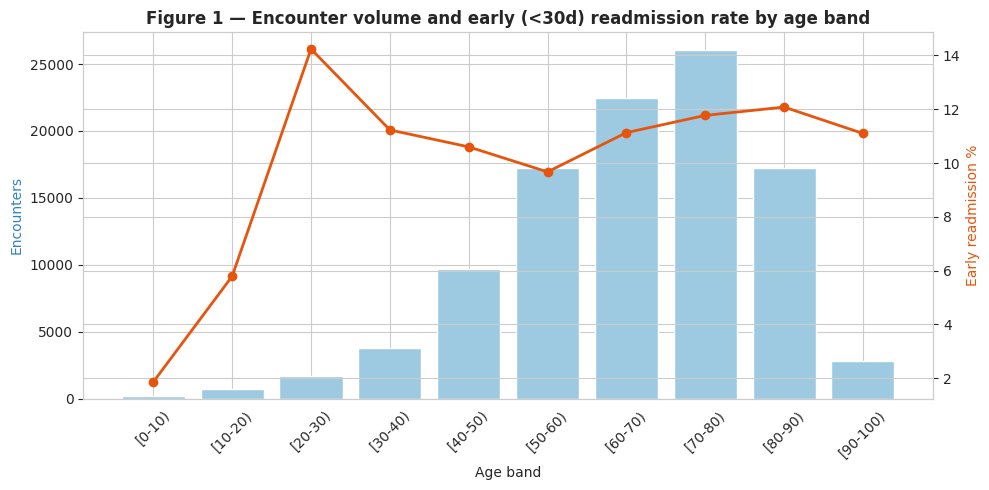

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Figure 1: encounter volume + early-readmission rate by age band
age_pdf = spark.sql("""
    SELECT age, COUNT(*) AS encounters,
           ROUND(100 * AVG(readmit_30d), 2) AS rate
    FROM encounters GROUP BY age ORDER BY age
""").toPandas()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(age_pdf["age"], age_pdf["encounters"], color="#9ecae1", label="Encounters")
ax1.set_xlabel("Age band"); ax1.set_ylabel("Encounters", color="#3182bd")
plt.xticks(rotation=45)
ax2 = ax1.twinx()
ax2.plot(age_pdf["age"], age_pdf["rate"], color="#e6550d", marker="o", lw=2, label="Early readmit %")
ax2.set_ylabel("Early readmission %", color="#e6550d")
plt.title("Figure 1 — Encounter volume and early (<30d) readmission rate by age band", fontweight="bold")
plt.tight_layout(); plt.savefig("fig_t1_age.png", dpi=150, bbox_inches="tight"); plt.show()

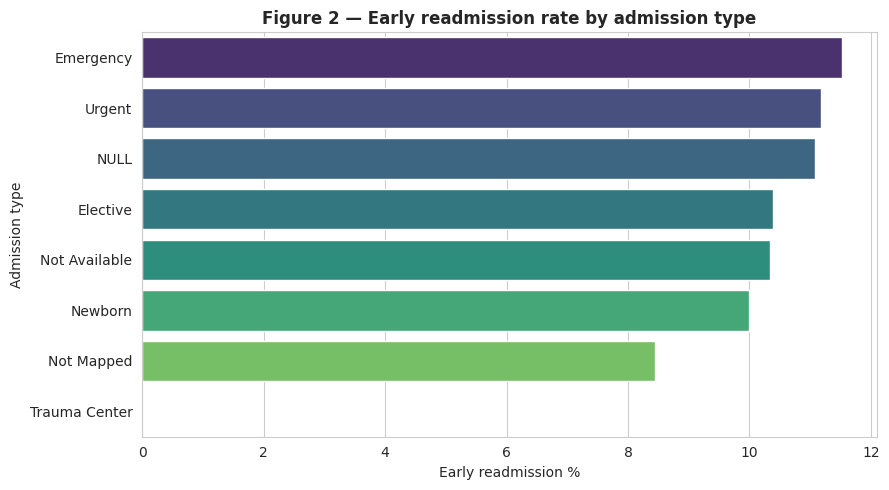

In [41]:
adm_pdf = spark.sql("""
    SELECT a.description AS admission_type,
           ROUND(100 * AVG(e.readmit_30d), 2) AS rate
    FROM encounters e JOIN admission_type a
      ON e.admission_type_id = a.admission_type_id
    GROUP BY a.description ORDER BY rate DESC
""").toPandas()

plt.figure(figsize=(9, 5))
sns.barplot(data=adm_pdf, y="admission_type", x="rate",
            hue="admission_type", palette="viridis", legend=False)
plt.xlabel("Early readmission %"); plt.ylabel("Admission type")
plt.title("Figure 2 — Early readmission rate by admission type", fontweight="bold")
plt.tight_layout(); plt.savefig("fig_t1_admission.png", dpi=150, bbox_inches="tight"); plt.show()

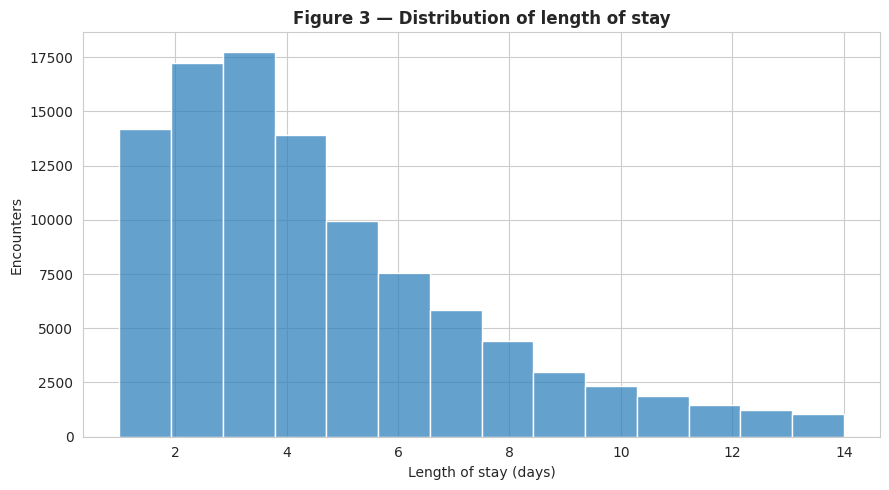

In [42]:
# Figure 3: distribution of length of stay
los_pdf = df_enriched.select("time_in_hospital").toPandas()

plt.figure(figsize=(9, 5))
sns.histplot(los_pdf["time_in_hospital"], bins=14, color="#3182bd")
plt.xlabel("Length of stay (days)"); plt.ylabel("Encounters")
plt.title("Figure 3 — Distribution of length of stay", fontweight="bold")
plt.tight_layout(); plt.savefig("fig_t1_los.png", dpi=150, bbox_inches="tight"); plt.show()

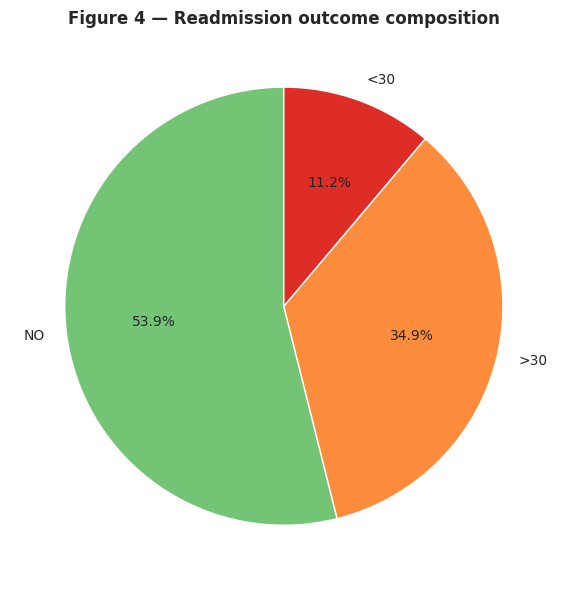

In [43]:
# Figure 4: overall readmission composition
out_pdf = df_enriched.groupBy("readmitted").count().toPandas()
order = {"NO": 0, ">30": 1, "<30": 2}
out_pdf = out_pdf.sort_values("readmitted", key=lambda s: s.map(order))

plt.figure(figsize=(6, 6))
plt.pie(out_pdf["count"], labels=out_pdf["readmitted"], autopct="%1.1f%%",
        colors=["#74c476", "#fd8d3c", "#de2d26"], startangle=90)
plt.title("Figure 4 — Readmission outcome composition", fontweight="bold")
plt.tight_layout(); plt.savefig("fig_t1_outcome.png", dpi=150, bbox_inches="tight"); plt.show()

# Machine Learning Classification with PySpark MLlib

## 1.1 Reload Dataset for the ML Pipeline


In [44]:
from pyspark.sql.functions import col, when, trim
from pyspark.sql.types import StringType

df_raw = spark.read.csv("diabetic_data.csv", header=True, inferSchema=True)

clean_cols = [c.strip().replace(" ", "_").replace("%", "pct") for c in df_raw.columns]
df_raw = df_raw.toDF(*clean_cols)

string_cols = [f.name for f in df_raw.schema.fields if isinstance(f.dataType, StringType)]
for c in string_cols:
    df_raw = df_raw.withColumn(c, when(trim(col(c)) == "?", None).otherwise(col(c)))

print(f"Loaded: {df_raw.count():,} rows × {len(df_raw.columns)} columns")
df_raw.printSchema()

Loaded: 101,766 rows × 50 columns
root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagno

## 2.2 Check for Missing Values

In [45]:
from pyspark.sql.functions import isnull, isnan

print("=" * 55)
print("MISSING VALUE AUDIT (top offenders)")
print("=" * 55)

total_rows = df_raw.count()
missing = []
for c_name, dtype in df_raw.dtypes:
    if dtype in ("double", "float", "int", "integer", "long"):
        null_count = df_raw.filter(isnull(col(c_name)) | isnan(col(c_name))).count()
    else:
        null_count = df_raw.filter(isnull(col(c_name)) | (col(c_name) == "")).count()
    missing.append((c_name, dtype, null_count, null_count / total_rows * 100))

for c_name, dtype, null_count, pct in sorted(missing, key=lambda x: -x[2])[:10]:
    print(f"  {c_name:<22} {dtype:<8} {null_count:>7,} missing  ({pct:.1f}%)")

print(f"\nTotal rows: {total_rows:,}")

MISSING VALUE AUDIT (top offenders)
  weight                 string    98,569 missing  (96.9%)
  medical_specialty      string    49,949 missing  (49.1%)
  payer_code             string    40,256 missing  (39.6%)
  race                   string     2,273 missing  (2.2%)
  diag_3                 string     1,423 missing  (1.4%)
  diag_2                 string       358 missing  (0.4%)
  diag_1                 string        21 missing  (0.0%)
  encounter_id           int            0 missing  (0.0%)
  patient_nbr            int            0 missing  (0.0%)
  gender                 string         0 missing  (0.0%)

Total rows: 101,766


## 2.3 Handle Missing Values and Clean Data

In [46]:
before   = df_raw.count()
df_clean = df_raw.dropDuplicates()
print(f"Duplicates removed: {before - df_clean.count()}")

expired = [11, 13, 14, 19, 20, 21]
df_clean = df_clean.filter(~col("discharge_disposition_id").isin(expired))

cols_to_drop = ["encounter_id", "patient_nbr", "weight", "payer_code", "medical_specialty"]
df_clean = df_clean.drop(*[c for c in cols_to_drop if c in df_clean.columns])

df_clean = df_clean.withColumn("label_str",
    when(col("readmitted") == "NO", "No").otherwise("Yes"))

keep = ["race","gender","age","A1Cresult","max_glu_serum","insulin","change","diabetesMed",
        "time_in_hospital","num_lab_procedures","num_procedures","num_medications",
        "number_outpatient","number_emergency","number_inpatient","number_diagnoses","label_str"]
df_clean = df_clean.select(*keep).na.fill("None")

print(f"\nClean dataset: {df_clean.count():,} rows × {len(df_clean.columns)} columns")
print(f"Remaining columns: {df_clean.columns}")

Duplicates removed: 0

Clean dataset: 99,343 rows × 17 columns
Remaining columns: ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'insulin', 'change', 'diabetesMed', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'label_str']


## 2.4 Verify Target Variable Balance


In [47]:
print("Target Variable Distribution — readmit_flag (label_str)")
print("-" * 50)

target_dist = df_clean.groupBy("label_str").count().orderBy("count", ascending=False)
target_dist.show()

total = df_clean.count()
for row in target_dist.collect():
    pct = row["count"] / total * 100
    print(f"  {row['label_str']:<6} : {row['count']:>6,} rows  ({pct:.1f}%)")

Target Variable Distribution — readmit_flag (label_str)
--------------------------------------------------
+---------+-----+
|label_str|count|
+---------+-----+
|       No|52527|
|      Yes|46816|
+---------+-----+

  No     : 52,527 rows  (52.9%)
  Yes    : 46,816 rows  (47.1%)


## 3.1 Encode Categorical Variables with StringIndexer

In [48]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

categorical_cols = ["race", "gender", "age", "A1Cresult", "max_glu_serum",
                    "insulin", "change", "diabetesMed"]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

label_indexer = StringIndexer(inputCol="label_str", outputCol="label", handleInvalid="keep")

indexer_pipeline = Pipeline(stages=indexers + [label_indexer])
df_indexed       = indexer_pipeline.fit(df_clean).transform(df_clean)

print("Categorical columns encoded")
print("\nSample encoded values:")
df_indexed.select("age","age_idx","insulin","insulin_idx",
                  "diabetesMed","diabetesMed_idx","label_str","label").show(5)

Categorical columns encoded

Sample encoded values:
+-------+-------+-------+-----------+-----------+---------------+---------+-----+
|    age|age_idx|insulin|insulin_idx|diabetesMed|diabetesMed_idx|label_str|label|
+-------+-------+-------+-----------+-----------+---------------+---------+-----+
|[70-80)|    0.0|     No|        0.0|        Yes|            0.0|      Yes|  1.0|
|[80-90)|    3.0|     No|        0.0|         No|            1.0|       No|  0.0|
|[80-90)|    3.0|     No|        0.0|        Yes|            0.0|      Yes|  1.0|
|[70-80)|    0.0|     No|        0.0|        Yes|            0.0|      Yes|  1.0|
|[70-80)|    0.0|     No|        0.0|         No|            1.0|       No|  0.0|
+-------+-------+-------+-----------+-----------+---------------+---------+-----+
only showing top 5 rows



## 3.2 Feature Selection and VectorAssembler


In [49]:
from pyspark.ml.feature import VectorAssembler

numeric_cols = ["time_in_hospital","num_lab_procedures","num_procedures","num_medications",
                "number_outpatient","number_emergency","number_inpatient","number_diagnoses"]

feature_cols = numeric_cols + [f"{c}_idx" for c in categorical_cols]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="keep")
df_assembled = assembler.transform(df_indexed)

print(f"VectorAssembler applied")
print(f"   Number of features : {len(feature_cols)}")
print(f"   Feature names      : {feature_cols}")
print()
df_assembled.select("features","label").show(3, truncate=False)

VectorAssembler applied
   Number of features : 16
   Feature names      : ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'race_idx', 'gender_idx', 'age_idx', 'A1Cresult_idx', 'max_glu_serum_idx', 'insulin_idx', 'change_idx', 'diabetesMed_idx']

+------------------------------------------------------------------+-----+
|features                                                          |label|
+------------------------------------------------------------------+-----+
|(16,[0,1,3,7,9],[3.0,51.0,13.0,7.0,1.0])                          |1.0  |
|(16,[0,1,3,7,10,15],[6.0,44.0,8.0,5.0,3.0,1.0])                   |0.0  |
|(16,[0,1,3,4,5,6,7,10,14],[2.0,66.0,18.0,1.0,2.0,2.0,9.0,3.0,1.0])|1.0  |
+------------------------------------------------------------------+-----+
only showing top 3 rows



## 3.3 Train / Test Split
80% for training, 20% held out for evaluation.

In [50]:
df_ml = df_assembled.select("features", "label")

train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

train_count = train_df.count()
test_count  = test_df.count()
total       = train_count + test_count

print("Train / Test split complete")
print(f"   Training set : {train_count:>6,} rows  ({train_count/total*100:.1f}%)")
print(f"   Test set     : {test_count:>6,} rows  ({test_count/total*100:.1f}%)")
print(f"   Total        : {total:>6,} rows")

Train / Test split complete
   Training set : 79,532 rows  (80.1%)
   Test set     : 19,811 rows  (19.9%)
   Total        : 99,343 rows


## 4.1 Train Random Forest Primary Model

In [51]:
from pyspark.ml.classification import RandomForestClassifier
import time

print("Training Random Forest Classifier...")
print("numTrees=100 | maxDepth=10 | seed=42")
print("-" * 42)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    seed=42
)

start    = time.time()
rf_model = rf.fit(train_df)
elapsed  = time.time() - start

print(f"\nRandom Forest trained in {elapsed:.1f} seconds")
print(f"   Number of trees : {rf_model.getNumTrees}")
print(f"   Total nodes     : {rf_model.totalNumNodes}")

Training Random Forest Classifier...
numTrees=100 | maxDepth=10 | seed=42
------------------------------------------

Random Forest trained in 126.9 seconds
   Number of trees : 100
   Total nodes     : 94758


## 4.2 Feature Importance
Random Forest scores how much each feature contributes to reducing prediction error across all trees.

In [52]:
import pandas as pd

importances = rf_model.featureImportances.toArray()

feat_imp_df = pd.DataFrame({
    "Feature":    feature_cols,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature Importance — Random Forest")
print("=" * 50)
for _, row in feat_imp_df.iterrows():
    bar = "#" * int(row["Importance"] * 100)
    print(f"  {row['Feature']:<22}  {row['Importance']:.4f}  {bar}")

Feature Importance — Random Forest
  number_inpatient        0.4071  ########################################
  number_emergency        0.0889  ########
  number_diagnoses        0.0869  ########
  number_outpatient       0.0628  ######
  num_medications         0.0613  ######
  age_idx                 0.0588  #####
  num_lab_procedures      0.0512  #####
  time_in_hospital        0.0361  ###
  insulin_idx             0.0295  ##
  num_procedures          0.0285  ##
  race_idx                0.0246  ##
  max_glu_serum_idx       0.0191  #
  diabetesMed_idx         0.0169  #
  A1Cresult_idx           0.0160  #
  gender_idx              0.0071  
  change_idx              0.0052  


## 4.3 Generate Predictions on Test Set

In [53]:
rf_predictions = rf_model.transform(test_df)
rf_predictions.cache()
rf_predictions.count()

print("Sample predictions — Random Forest:")
rf_predictions.select("label","prediction","probability").show(10, truncate=False)

Sample predictions — Random Forest:
+-----+----------+--------------------------------------------+
|label|prediction|probability                                 |
+-----+----------+--------------------------------------------+
|1.0  |1.0       |[0.4295112842025339,0.5704887157974661,0.0] |
|1.0  |0.0       |[0.5244813047575518,0.4755186952424483,0.0] |
|0.0  |1.0       |[0.44955481306726625,0.5504451869327337,0.0]|
|0.0  |0.0       |[0.6170395688827077,0.38296043111729233,0.0]|
|0.0  |1.0       |[0.3728763179072568,0.6271236820927433,0.0] |
|1.0  |0.0       |[0.5853961874372997,0.41460381256270035,0.0]|
|0.0  |1.0       |[0.39979968008962896,0.600200319910371,0.0] |
|1.0  |1.0       |[0.43393387656268934,0.5660661234373107,0.0]|
|0.0  |1.0       |[0.42994698689759037,0.5700530131024096,0.0]|
|0.0  |1.0       |[0.44943350036404994,0.55056649963595,0.0]  |
+-----+----------+--------------------------------------------+
only showing top 10 rows



## 5.1 Train Logistic Regression Alternative Model

In [54]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)
scaler_model = scaler.fit(train_df)
train_scaled = scaler_model.transform(train_df)
test_scaled  = scaler_model.transform(test_df)
print("Features standardised (mean=0, std=1)")

print("\nTraining Logistic Regression...")
print("maxIter=100 | regParam=0.01 | elasticNetParam=0.0")
print("-" * 48)

lr = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="label",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

start    = time.time()
lr_model = lr.fit(train_scaled)
elapsed  = time.time() - start

print(f"\nLogistic Regression trained in {elapsed:.1f} seconds")
print(f"   Iterations to convergence: {lr_model.summary.totalIterations}")

Features standardised (mean=0, std=1)

Training Logistic Regression...
maxIter=100 | regParam=0.01 | elasticNetParam=0.0
------------------------------------------------

Logistic Regression trained in 16.0 seconds
   Iterations to convergence: 48


In [55]:
lr_predictions = lr_model.transform(test_scaled)
lr_predictions.cache()
lr_predictions.count()

print("Sample predictions — Logistic Regression:")
lr_predictions.select("label","prediction","probability").show(10, truncate=False)

rf_correct = rf_predictions.filter(col("prediction") == col("label")).count()
lr_correct = lr_predictions.filter(col("prediction") == col("label")).count()
print(f"\nQuick Accuracy Snapshot:")
print(f"  Random Forest       : {rf_correct/rf_predictions.count()*100:.2f}%")
print(f"  Logistic Regression : {lr_correct/lr_predictions.count()*100:.2f}%")

Sample predictions — Logistic Regression:
+-----+----------+-------------------------------------------------------------+
|label|prediction|probability                                                  |
+-----+----------+-------------------------------------------------------------+
|1.0  |0.0       |[0.5055593732234017,0.4944406254840749,1.292523388150469E-9] |
|1.0  |0.0       |[0.5405563948558008,0.4594436038561152,1.288083937514337E-9] |
|0.0  |1.0       |[0.3661412513975873,0.6338587473568127,1.245599910541146E-9] |
|0.0  |1.0       |[0.48401942351550553,0.5159805751927533,1.291741244137312E-9]|
|0.0  |1.0       |[0.4247219518341735,0.5752780468885805,1.2772461875195133E-9]|
|1.0  |0.0       |[0.6498086314957326,0.35019136727140526,1.232862074605961E-9]|
|0.0  |1.0       |[0.44503459540683654,0.554965403308935,1.2842286125523988E-9]|
|1.0  |0.0       |[0.521265955181243,0.4787340435279198,1.2908372330099278E-9] |
|0.0  |1.0       |[0.45053173244408057,0.549468266270243,1.28567624

## 6.1 Evaluation Metrics

In [56]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.feature import VectorSlicer

def evaluate_model(predictions, model_name):
    multi_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

    accuracy  = multi_eval.evaluate(predictions, {multi_eval.metricName: "accuracy"})
    precision = multi_eval.evaluate(predictions, {multi_eval.metricName: "weightedPrecision"})
    recall    = multi_eval.evaluate(predictions, {multi_eval.metricName: "weightedRecall"})
    f1        = multi_eval.evaluate(predictions, {multi_eval.metricName: "f1"})

    # StringIndexer(handleInvalid="keep") reserves an extra class slot, so the
    # rawPrediction vector has length 3. Slice the two real classes for AUC.
    preds_binary = predictions.filter(col("label") < 2)
    slicer = VectorSlicer(inputCol="rawPrediction", outputCol="rawPred_binary", indices=[0, 1])
    preds_sliced = slicer.transform(preds_binary)

    binary_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPred_binary")
    auc = binary_eval.evaluate(preds_sliced, {binary_eval.metricName: "areaUnderROC"})

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")

    return {"Model": model_name, "Accuracy": round(accuracy,4), "Precision": round(precision,4),
            "Recall": round(recall,4), "F1": round(f1,4), "AUC": round(auc,4)}

rf_metrics = evaluate_model(rf_predictions, "Random Forest")
lr_metrics = evaluate_model(lr_predictions, "Logistic Regression")


  Random Forest — Evaluation Results
  Accuracy  : 0.6418  (64.18%)
  Precision : 0.6420
  Recall    : 0.6418
  F1-Score  : 0.6360
  AUC-ROC   : 0.6947

  Logistic Regression — Evaluation Results
  Accuracy  : 0.6192  (61.92%)
  Precision : 0.6227
  Recall    : 0.6192
  F1-Score  : 0.6049
  AUC-ROC   : 0.6557


## 6.2 Confusion Matrix

In [57]:
def confusion_matrix(predictions, model_name):
    print(f"\nConfusion Matrix — {model_name}")
    print("-" * 44)

    cm_data = predictions.groupBy("label","prediction").count().orderBy("label","prediction").collect()
    label_map = {0.0: "No", 1.0: "Yes"}
    matrix    = {(r["label"], r["prediction"]): r["count"] for r in cm_data}

    print(f"  {'':>14}  {'Pred No':>10}  {'Pred Yes':>10}")
    print(f"  {'-'*40}")
    for actual in [0.0, 1.0]:
        p0 = matrix.get((actual, 0.0), 0)
        p1 = matrix.get((actual, 1.0), 0)
        print(f"  {'Act '+label_map[actual]:>14}  {p0:>10,}  {p1:>10,}")
    return matrix

rf_cm = confusion_matrix(rf_predictions, "Random Forest")
lr_cm = confusion_matrix(lr_predictions, "Logistic Regression")


Confusion Matrix — Random Forest
--------------------------------------------
                     Pred No    Pred Yes
  ----------------------------------------
          Act No       8,039       2,619
         Act Yes       4,499       4,716

Confusion Matrix — Logistic Regression
--------------------------------------------
                     Pred No    Pred Yes
  ----------------------------------------
          Act No       8,424       2,234
         Act Yes       5,333       3,882


## 7.1 Metric Comparison Bar Chart

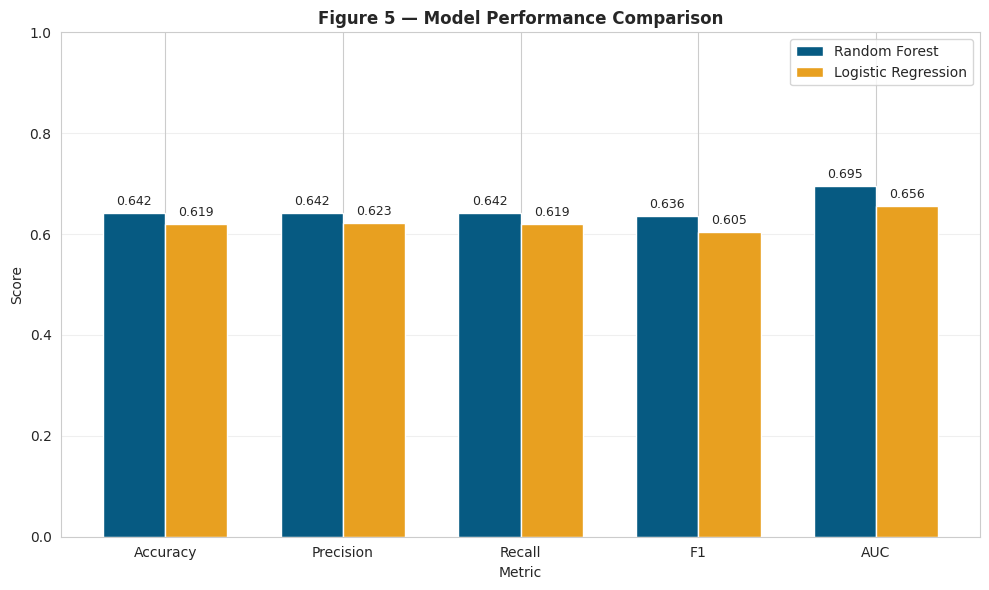

In [65]:
import numpy as np

metrics = ["Accuracy","Precision","Recall","F1","AUC"]
rf_vals = [rf_metrics[m] for m in metrics]
lr_vals = [lr_metrics[m] for m in metrics]

x = np.arange(len(metrics)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rf_vals, width, label="Random Forest", color="#065A82")
bars2 = ax.bar(x + width/2, lr_vals, width, label="Logistic Regression", color="#E8A020")
ax.set_xlabel("Metric"); ax.set_ylabel("Score")
ax.set_title("Figure 5 — Model Performance Comparison", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, 1.0); ax.legend(); ax.grid(axis="y", alpha=0.3)
for b in list(bars1)+list(bars2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{b.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.savefig("metric_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

## 7.2 Confusion Matrix Heatmaps

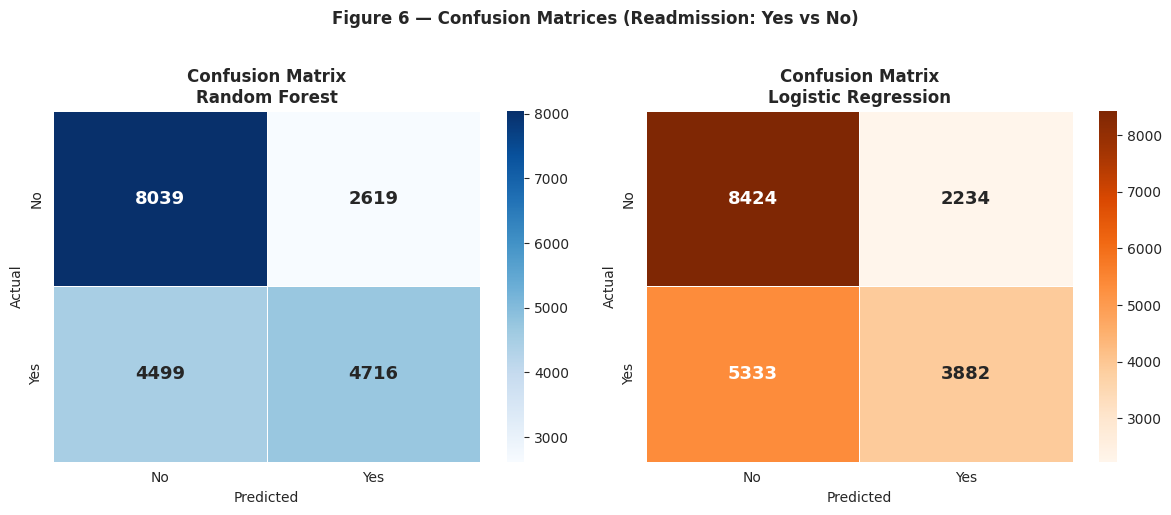

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classes = ["No", "Yes"]
for ax, cm_data, title, cmap in zip(axes, [rf_cm, lr_cm],
        ["Random Forest", "Logistic Regression"], ["Blues", "Oranges"]):
    arr = np.array([[cm_data.get((0.0,0.0),0), cm_data.get((0.0,1.0),0)],
                    [cm_data.get((1.0,0.0),0), cm_data.get((1.0,1.0),0)]])
    sns.heatmap(arr, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(f"Confusion Matrix\n{title}", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Figure 6 — Confusion Matrices (Readmission: Yes vs No)", fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight"); plt.show()

## 7.3 ROC Curve

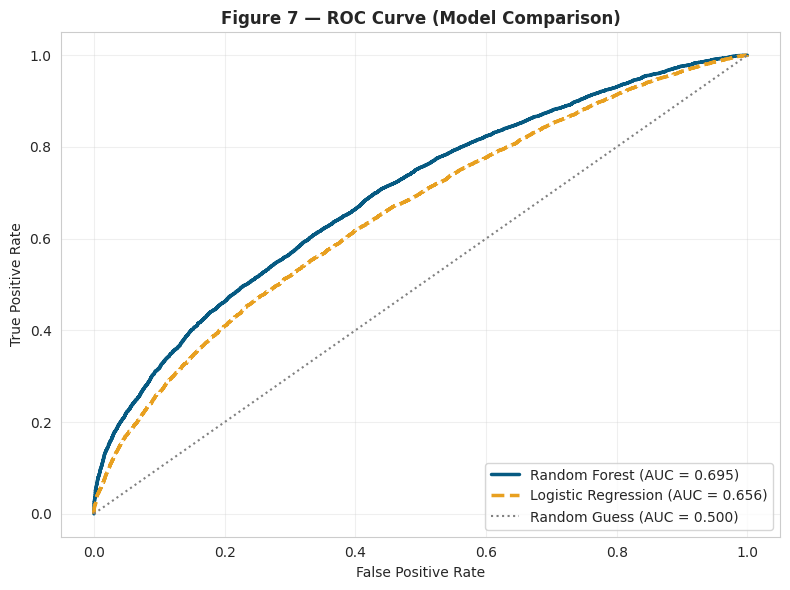

In [67]:
from sklearn.metrics import roc_curve, auc as sk_auc

def get_roc_data(predictions):
    rows    = predictions.select("label","probability").collect()
    y_true  = [int(r["label"]) for r in rows]
    y_score = [float(r["probability"][1]) for r in rows]
    return y_true, y_score

rf_y_true, rf_y_score = get_roc_data(rf_predictions)
lr_y_true, lr_y_score = get_roc_data(lr_predictions)
rf_fpr, rf_tpr, _ = roc_curve(rf_y_true, rf_y_score)
lr_fpr, lr_tpr, _ = roc_curve(lr_y_true, lr_y_score)
rf_auc_sk = sk_auc(rf_fpr, rf_tpr); lr_auc_sk = sk_auc(lr_fpr, lr_tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rf_fpr, rf_tpr, color="#065A82", lw=2.5, label=f"Random Forest (AUC = {rf_auc_sk:.3f})")
ax.plot(lr_fpr, lr_tpr, color="#E8A020", lw=2.5, linestyle="--", label=f"Logistic Regression (AUC = {lr_auc_sk:.3f})")
ax.plot([0,1],[0,1], color="grey", lw=1.5, linestyle=":", label="Random Guess (AUC = 0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 7 — ROC Curve (Model Comparison)", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight"); plt.show()

## 7.4 Feature Importance Chart and Summary Table

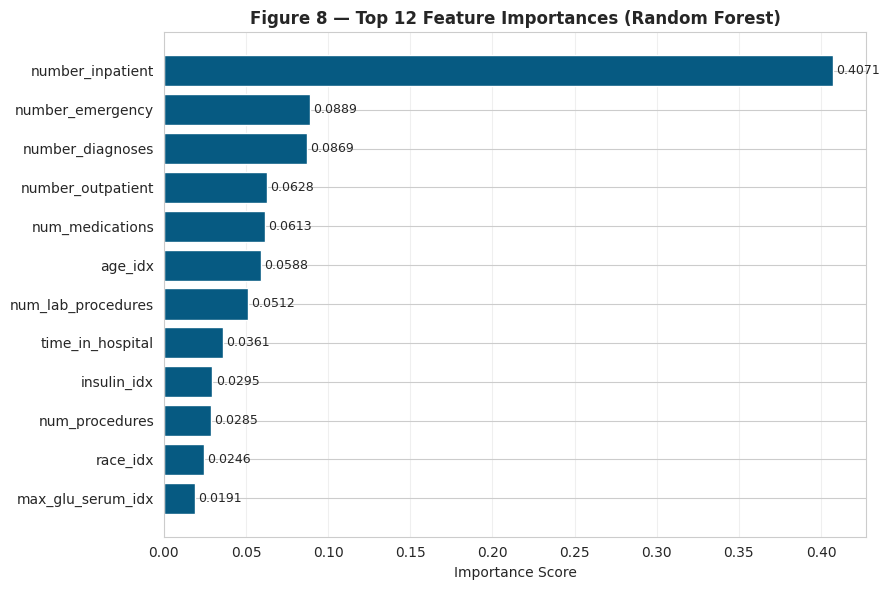


  FINAL MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Random Forest          0.6418     0.6420  0.6418  0.6360  0.6947
Logistic Regression    0.6192     0.6227  0.6192  0.6049  0.6557

Best model per metric:
  Accuracy  : Random Forest          (0.6418)
  Precision : Random Forest          (0.6420)
  Recall    : Random Forest          (0.6418)
  F1        : Random Forest          (0.6360)
  AUC       : Random Forest          (0.6947)


In [68]:
top_n     = 12
top_feats = feat_imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_feats["Feature"][::-1], top_feats["Importance"][::-1],
               color="#065A82", edgecolor="white")
for bar, val in zip(bars, top_feats["Importance"][::-1]):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
ax.set_xlabel("Importance Score")
ax.set_title(f"Figure 8 — Top {top_n} Feature Importances (Random Forest)", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight"); plt.show()

# Summary table
summary = pd.DataFrame([rf_metrics, lr_metrics]).set_index("Model")
print("\n" + "="*55)
print("  FINAL MODEL COMPARISON SUMMARY")
print("="*55)
print(summary.to_string())
print("="*55)
print("\nBest model per metric:")
for m in metrics:
    print(f"  {m:<10}: {summary[m].idxmax():<22} ({summary[m].max():.4f})")

## 8 Save Models & Export

In [62]:
# Save both trained models
rf_model.save("model_random_forest")
lr_model.save("model_logistic_regression")

print(" Models saved:")
print("   ./model_random_forest/")
print("   ./model_logistic_regression/")

# Verify by reloading
from pyspark.ml.classification import (
    RandomForestClassificationModel,
    LogisticRegressionModel
)
rf_loaded = RandomForestClassificationModel.load("model_random_forest")
lr_loaded = LogisticRegressionModel.load("model_logistic_regression")
print("\nModels reloaded and verified")
print(f"   RF trees    : {rf_loaded.getNumTrees}")
print(f"   LR features : {lr_loaded.numFeatures}")

 Models saved:
   ./model_random_forest/
   ./model_logistic_regression/

Models reloaded and verified
   RF trees    : 100
   LR features : 16


### 8.2 Download All Output Files


In [63]:
### 8.2 Download All Output Files


In [69]:
from google.colab import files as colab_files
import zipfile, os

output_files = [
    "metric_comparison.png",
    "confusion_matrices.png",
    "roc_curve.png",
    "feature_importance.png"
]

with zipfile.ZipFile("LNDN5204_Task2_Outputs.zip", "w") as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"  Added: {f}")
        else:
            print(f"    Not found (run Section 7 first): {f}")

print("\nDownloading archive...")
colab_files.download("LNDN5204_Task2_Outputs.zip")

  Added: metric_comparison.png
  Added: confusion_matrices.png
  Added: roc_curve.png
  Added: feature_importance.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>